In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [2]:
diabetes = pd.read_csv('/content/Naive-Bayes-Classification-Data.csv')
diabetes.head()

,glucose,bloodpressure,diabetes
0,40,85,0
1,40,92,0
2,45,63,1
3,45,80,0
4,40,73,1


In [4]:
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   glucose        995 non-null    int64
 1   bloodpressure  995 non-null    int64
 2   diabetes       995 non-null    int64
dtypes: int64(3)
memory usage: 23.4 KB


In [5]:
diabetes.describe()

,glucose,bloodpressure,diabetes
count,995.000000,995.000000,995.000000
mean,44.306533,79.184925,0.500503
std,6.707567,9.340204,0.500251
min,20.000000,50.000000,0.000000
25%,40.000000,72.000000,0.000000
50%,45.000000,80.000000,1.000000
75%,50.000000,87.000000,1.000000
max,70.000000,100.000000,1.000000


In [7]:
diabetes.isna().sum()

glucose          0
bloodpressure    0
diabetes         0
dtype: int64

In [3]:
x = diabetes.drop('diabetes', axis=1)
y = diabetes['diabetes']
x.shape, y.shape

((995, 2), (995,))

In [8]:
scaler = MinMaxScaler()
x = pd.DataFrame(scaler.fit_transform(x), columns=x.columns.values)
x.head()

,glucose,bloodpressure
0,0.4,0.70
1,0.4,0.84
2,0.5,0.26
3,0.5,0.60
4,0.4,0.46


In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, train_size=0.80)
x_test, x_valid, y_test, y_valid = train_test_split(x_test, y_test, stratify=y_test, train_size=0.5)
x_train.shape, x_test.shape, x_valid.shape, y_train.shape, y_test.shape, y_valid.shape

((796, 2), (99, 2), (100, 2), (796,), (99,), (100,))

## Classification

### Gaussian

In [10]:
gaussian_nb = GaussianNB()
gaussian_nb.fit(x_train, y_train)

GaussianNB()

In [11]:
gaussian_cv = cross_validate(estimator=gaussian_nb,
                             X=x_valid, y=y_valid,
                             scoring='accuracy', cv=5,
                             return_train_score=True)
gaussian_mean_train_score = round((gaussian_cv['train_score'] * 100).mean(), 3)
gaussian_mean_test_score = round((gaussian_cv['test_score'] * 100).mean(), 3)
print(f'Mean train score: {gaussian_mean_train_score}')
print(f'Mean test score: {gaussian_mean_test_score}')

Mean train score: 98.5
Mean test score: 98.0


In [12]:
gaussian_predict = gaussian_nb.predict(x_test)
print(classification_report(y_test, gaussian_predict))

              precision    recall  f1-score   support

           0       0.93      0.84      0.88        49
           1       0.85      0.94      0.90        50

    accuracy                           0.89        99
   macro avg       0.89      0.89      0.89        99
weighted avg       0.89      0.89      0.89        99



### Bernoulli

In [13]:
bernoulli_nb = BernoulliNB()
bernoulli_nb.fit(x_train, y_train)

BernoulliNB()

In [14]:
bernoulli_cv = cross_validate(estimator=bernoulli_nb,
                              X=x_valid, y=y_valid,
                             cv=5, return_train_score=True)
bernoulli_mean_train_score = round((bernoulli_cv['train_score'] * 100).mean(), 3)
bernoulli_mean_test_score = round((bernoulli_cv['test_score'] * 100).mean(), 3)
print(f'Mean train score: {bernoulli_mean_train_score}')
print(f'Mean test score: {bernoulli_mean_test_score}')

Mean train score: 50.0
Mean test score: 50.0


In [15]:
bernoulli_predict = gaussian_nb.predict(x_test)
print(classification_report(y_test, bernoulli_predict))

              precision    recall  f1-score   support

           0       0.93      0.84      0.88        49
           1       0.85      0.94      0.90        50

    accuracy                           0.89        99
   macro avg       0.89      0.89      0.89        99
weighted avg       0.89      0.89      0.89        99



### Multinomial

In [16]:
multinomial_nb = MultinomialNB()
multinomial_nb.fit(x_train, y_train)

MultinomialNB()

In [17]:
multinomial_cv = cross_validate(estimator=multinomial_nb,
                               X=x_valid, y=y_valid,
                               cv=5, return_train_score=True)
multinomial_mean_train_score = round((multinomial_cv['train_score'] * 100).mean(), 3)
multinomial_mean_test_score = round((multinomial_cv['test_score'] * 100).mean(), 3)
print(f'Mean train score: {multinomial_mean_train_score}')
print(f'Mean test score: {multinomial_mean_test_score}')

Mean train score: 85.0
Mean test score: 84.0


In [18]:
multinomial_predict = multinomial_nb.predict(x_test)
print(classification_report(y_test, multinomial_predict))

              precision    recall  f1-score   support

           0       0.72      0.90      0.80        49
           1       0.87      0.66      0.75        50

    accuracy                           0.78        99
   macro avg       0.79      0.78      0.78        99
weighted avg       0.80      0.78      0.77        99



## Comparison of Results

In [19]:
sns.set_theme(style='whitegrid')

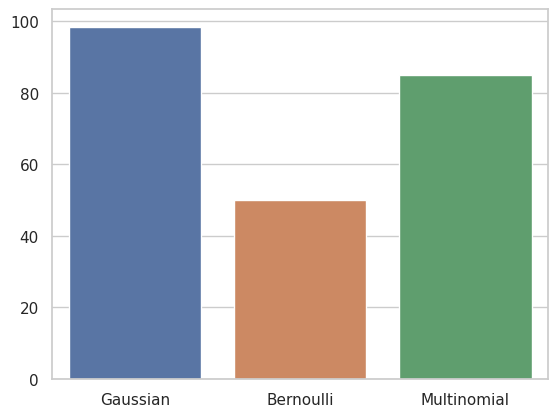

In [20]:
mean_train_scores = pd.DataFrame(data=[[gaussian_mean_train_score,
                                        bernoulli_mean_train_score,
                                        multinomial_mean_train_score]],
                                 columns=['Gaussian', 'Bernoulli', 'Multinomial'])
sns.barplot(data=mean_train_scores);

<Axes: >

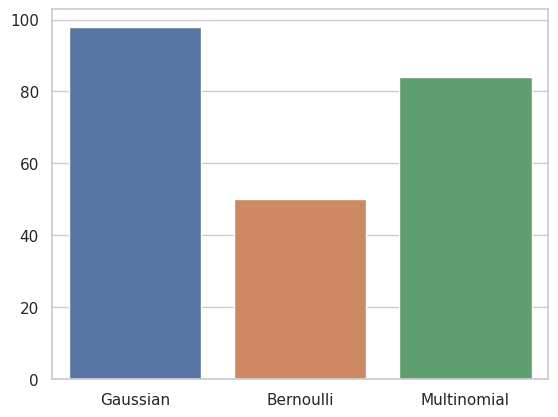

In [21]:
mean_test_scores = pd.DataFrame(data=[[gaussian_mean_test_score,
                                      bernoulli_mean_test_score,
                                      multinomial_mean_test_score]],
                                columns=['Gaussian', 'Bernoulli', 'Multinomial'])
sns.barplot(data=mean_test_scores)